
# FACED sqrt-JSD training monitor

This is an **exploratory training diagnostic** for `native_sqrt_jsd` with HCBT. It reuses the completed FACED feature cache and does not repeat signal or feature extraction.

Every `EVAL_INTERVAL` epochs (default: 10), it displays:

- source-train, unseen source-validation, and official target accuracy;
- source-validation and target confusion matrices;
- loss, learning rate, gradient norm, prediction entropy, and class-collapse diagnostics.

The official target fold is **monitor-only**: it never contributes gradients, normalization, early stopping, checkpoint selection, or scheduler decisions. Because its metrics are repeatedly viewed, any conclusions from this notebook are development/exploratory evidence, not blind-test evidence.


## 1. Parameters ? edit this cell first

In [1]:

# ------------------------- Paths and split -------------------------
FACED_RUN_ROOT = "runs/faced_native_compact_base_seed42"
FACED_CONFIG = "configs/faced/native_compact_base.yaml"
FOLD = 1
SEED = 42
SOURCE_VALIDATION_SUBJECTS = 12   # held-out source subjects; never fit normalization on these
MONITOR_OFFICIAL_TARGET = True    # requested diagnostic; target never controls training
EVALUATE_AT_EPOCH_ZERO = True

# Each manual experiment should use a unique name.
RUN_NAME = "sqrt_jsd_fold01_manual_001"
ALLOW_OVERWRITE = False
SAVE_CHECKPOINTS = True

# ------------------------- Model -------------------------
D_MODEL = 1000
HEADS = 20
LAYERS = 6
FEEDFORWARD = 4000
DROPOUT = 0.1

# ------------------------- Optimization -------------------------
EPOCHS = 100
EVAL_INTERVAL = 10
BATCH_SIZE = 64
GRADIENT_ACCUMULATION_STEPS = 1
OPTIMIZER = "adamw"              # adamw | adam | sgd
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
ADAM_BETAS = (0.9, 0.999)
ADAM_EPS = 1e-8
SGD_MOMENTUM = 0.9
LABEL_SMOOTHING = 0.01
CLASS_WEIGHTING = "none"         # none | balanced
GRADIENT_CLIP_NORM = 1.0          # 0 disables clipping

# cosine_epoch matches the completed matrix. warmup_cosine updates every optimizer step.
SCHEDULER = "cosine_epoch"       # cosine_epoch | warmup_cosine | step | constant
MINIMUM_LEARNING_RATE = 1e-6
WARMUP_FRACTION = 0.0
STEP_SIZE_EPOCHS = 30
STEP_GAMMA = 0.3

# ------------------------- Runtime -------------------------
DEVICE = "auto"
PRECISION = "bfloat16"           # float32 | bfloat16 | float16
DETERMINISTIC = True
MATMUL_PRECISION = "high"
NUM_WORKERS = 0                   # 0 is the safest choice inside Jupyter on Windows
CACHE_NORMALIZED = True
SCALE_INPUTS = True



## 2. Setup and protocol checks

The repository is detected automatically from the notebook location/current directory. The cell refuses missing caches and verifies that the selected representation is `native_sqrt_jsd`.


In [2]:

from __future__ import annotations

import json
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import clear_output, display
from sklearn.metrics import confusion_matrix
from torch import nn


def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src" / "cmrd").is_dir() and (candidate / "configs" / "faced").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the CMRD repository or one of its subdirectories.")


REPO_ROOT = find_repo_root(Path.cwd())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from cmrd.config import load_config
from cmrd.faced import EMOTION_NAMES, official_fold_subjects
from cmrd.faced_runner import _load_samples
from cmrd.fixed_protocol import (
    _autocast,
    _forward_sequence_model,
    _loader,
    _shutdown_persistent_loader,
    _valid_indices_on_device,
    _warmup_cosine_scheduler,
    build_model,
    scaling_statistics,
)
from cmrd.io import read_json
from cmrd.models import HierarchicalChannelBandTransformer
from cmrd.training.metrics import classification_metrics
from cmrd.training.runtime import seed_everything, select_device

assert 1 <= FOLD <= 10
assert EPOCHS >= 1 and EVAL_INTERVAL >= 1 and BATCH_SIZE >= 1
assert SOURCE_VALIDATION_SUBJECTS >= 1 and GRADIENT_ACCUMULATION_STEPS >= 1
assert PRECISION in {"float32", "bfloat16", "float16"}
assert OPTIMIZER in {"adamw", "adam", "sgd"}
assert SCHEDULER in {"cosine_epoch", "warmup_cosine", "step", "constant"}
assert CLASS_WEIGHTING in {"none", "balanced"}

RUN_ROOT = (REPO_ROOT / FACED_RUN_ROOT).resolve()
CONFIG_PATH = (REPO_ROOT / FACED_CONFIG).resolve()
LOCK = read_json(RUN_ROOT / "experiment_lock.json")
PROTOCOL_HASH = str(LOCK["protocol_hash"])
CONFIG = load_config(CONFIG_PATH)
OUTPUT_DIR = REPO_ROOT / "runs" / "faced_sqrt_jsd_monitor" / RUN_NAME

if OUTPUT_DIR.exists() and any(OUTPUT_DIR.iterdir()) and not ALLOW_OVERWRITE:
    raise FileExistsError(
        f"{OUTPUT_DIR} already contains files. Change RUN_NAME or set ALLOW_OVERWRITE=True intentionally."
    )
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

seed_everything(SEED, DETERMINISTIC)
device = select_device(DEVICE)
if device.type == "cuda":
    torch.set_float32_matmul_precision(MATMUL_PRECISION)

print(f"Repository: {REPO_ROOT}")
print(f"Feature cache: {RUN_ROOT}")
print(f"Protocol hash: {PROTOCOL_HASH}")
print(f"Output: {OUTPUT_DIR}")
print(f"Device: {device}; precision: {PRECISION}")
if MONITOR_OFFICIAL_TARGET:
    print("WARNING: official target metrics are visible. This run is exploratory and target-monitored.")


Repository: C:\Users\Lin\Documents\Arbitruam\CMRD-Cute-Mew-Really-Delighting
Feature cache: C:\Users\Lin\Documents\Arbitruam\CMRD-Cute-Mew-Really-Delighting\runs\faced_native_compact_base_seed42
Protocol hash: 300ced3ac3b006d1
Output: C:\Users\Lin\Documents\Arbitruam\CMRD-Cute-Mew-Really-Delighting\runs\faced_sqrt_jsd_monitor\sqrt_jsd_fold01_manual_001
Device: cuda; precision: bfloat16



## 3. Load sqrt-JSD and make a source-only validation split

The official source subjects are split by subject, not by trial. Each FACED subject has all 28 videos/classes, so the validation subset remains class-complete. Normalization is fitted on `source_train` only.


In [3]:

source_subjects, target_subjects = official_fold_subjects(FOLD)
if SOURCE_VALIDATION_SUBJECTS >= len(source_subjects):
    raise ValueError("SOURCE_VALIDATION_SUBJECTS must be smaller than the official source set")

split_rng = np.random.default_rng(SEED + 10_000 * FOLD)
shuffled_source = split_rng.permutation(source_subjects)
source_validation_subjects = sorted(map(int, shuffled_source[:SOURCE_VALIDATION_SUBJECTS]))
source_train_subjects = sorted(map(int, shuffled_source[SOURCE_VALIDATION_SUBJECTS:]))

def load_subjects(subjects):
    return _load_samples(
        CONFIG, RUN_ROOT, FOLD, PROTOCOL_HASH, subjects, "native_sqrt_jsd"
    )

source_train_samples = load_subjects(source_train_subjects)
source_validation_samples = load_subjects(source_validation_subjects)
target_samples = load_subjects(target_subjects) if MONITOR_OFFICIAL_TARGET else []

normalization_mean, normalization_std = scaling_statistics(source_train_samples, SCALE_INPUTS)
input_dim = int(source_train_samples[0].x.shape[1])
max_length = max(sample.x.shape[0] for sample in source_train_samples + source_validation_samples + target_samples)

print(f"Fold {FOLD}: source train={len(source_train_subjects)} subjects/{len(source_train_samples)} trials")
print(f"Fold {FOLD}: source validation={len(source_validation_subjects)} subjects/{len(source_validation_samples)} trials")
print(f"Fold {FOLD}: official target={len(target_subjects)} subjects/{len(target_samples)} trials")
print(f"Input shape per trial: ({max_length}, {input_dim}); classes={len(EMOTION_NAMES)}")
print(f"Source-validation subjects: {source_validation_subjects}")
print(f"Official target subjects: {target_subjects}")
print(f"Normalizer std range: {normalization_std.min():.6g} .. {normalization_std.max():.6g}")

assert input_dim == 30 * 5
assert all(sample.subject not in target_subjects for sample in source_train_samples + source_validation_samples)
assert set(source_train_subjects).isdisjoint(source_validation_subjects)


Fold 1: source train=99 subjects/2772 trials
Fold 1: source validation=12 subjects/336 trials
Fold 1: official target=12 subjects/336 trials
Input shape per trial: (30, 150); classes=9
Source-validation subjects: [26, 31, 44, 55, 63, 77, 78, 79, 94, 107, 118, 122]
Official target subjects: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Normalizer std range: 0.0498928 .. 0.0974695


## 4. Build loaders, HCBT, optimizer, and scheduler

In [4]:

model_config = {
    "name": "hierarchical_attention",
    "channels": 30,
    "d_model": D_MODEL,
    "heads": HEADS,
    "layers": LAYERS,
    "feedforward": FEEDFORWARD,
    "dropout": DROPOUT,
}
model = build_model(model_config, input_dim, len(EMOTION_NAMES), max_length).to(device)

train_loader = _loader(
    source_train_samples, normalization_mean, normalization_std,
    BATCH_SIZE, True, SEED,
    num_workers=NUM_WORKERS,
    persistent_workers=False,
    prefetch_factor=1,
    cache_normalized=CACHE_NORMALIZED,
)
source_train_eval_loader = _loader(
    source_train_samples, normalization_mean, normalization_std,
    BATCH_SIZE, False, SEED, cache_normalized=CACHE_NORMALIZED,
)
source_validation_loader = _loader(
    source_validation_samples, normalization_mean, normalization_std,
    BATCH_SIZE, False, SEED, cache_normalized=CACHE_NORMALIZED,
)
target_loader = (
    _loader(target_samples, normalization_mean, normalization_std,
            BATCH_SIZE, False, SEED, cache_normalized=CACHE_NORMALIZED)
    if target_samples else None
)

if CLASS_WEIGHTING == "balanced":
    counts = np.bincount([sample.label for sample in source_train_samples], minlength=len(EMOTION_NAMES))
    class_weights = len(source_train_samples) / (len(EMOTION_NAMES) * counts)
    loss_weight = torch.tensor(class_weights, dtype=torch.float32, device=device)
else:
    loss_weight = None
criterion = nn.CrossEntropyLoss(weight=loss_weight, label_smoothing=LABEL_SMOOTHING)

if OPTIMIZER == "adamw":
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
                                  betas=ADAM_BETAS, eps=ADAM_EPS)
elif OPTIMIZER == "adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
                                 betas=ADAM_BETAS, eps=ADAM_EPS)
else:
    optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
                                momentum=SGD_MOMENTUM)

updates_per_epoch = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS)
if SCHEDULER == "cosine_epoch":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=MINIMUM_LEARNING_RATE
    )
    scheduler_per_update = False
elif SCHEDULER == "warmup_cosine":
    scheduler = _warmup_cosine_scheduler(
        optimizer, EPOCHS * updates_per_epoch, WARMUP_FRACTION, MINIMUM_LEARNING_RATE
    )
    scheduler_per_update = True
elif SCHEDULER == "step":
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=STEP_SIZE_EPOCHS, gamma=STEP_GAMMA
    )
    scheduler_per_update = False
else:
    scheduler = None
    scheduler_per_update = False

use_float16_scaler = device.type == "cuda" and PRECISION == "float16"
try:
    scaler = torch.amp.GradScaler("cuda", enabled=use_float16_scaler)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=use_float16_scaler)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"Parameters: {parameter_count:,}")
print(f"Optimizer={OPTIMIZER}, scheduler={SCHEDULER}, updates/epoch={updates_per_epoch}")


Parameters: 88,156,009
Optimizer=adamw, scheduler=cosine_epoch, updates/epoch=44



## 5. Monitoring helpers

At each monitoring point, the notebook evaluates three disjoint views:

- **source train**: detects whether optimization can fit the representation;
- **source validation**: unseen source subjects, used for the optional best-source checkpoint;
- **official target**: diagnostic only, never used for model selection.


In [5]:

@torch.no_grad()
def evaluate_loader(loader):
    model.eval()
    all_targets, all_predictions, all_probabilities = [], [], []
    loss_sum = 0.0
    count = 0
    for data, mask, labels in loader:
        valid_indices = _valid_indices_on_device(mask, device)
        data = data.to(device, non_blocking=True)
        mask_device = mask.to(device, non_blocking=True)
        labels_device = labels.to(device, non_blocking=True)
        with _autocast({"precision": PRECISION}, device):
            logits = _forward_sequence_model(model, data, mask_device, valid_indices)
            loss = criterion(logits, labels_device)
        probabilities = torch.softmax(logits.float(), dim=1)
        loss_sum += float(loss.item()) * labels.shape[0]
        count += int(labels.shape[0])
        all_targets.append(labels.numpy())
        all_predictions.append(logits.argmax(dim=1).cpu().numpy())
        all_probabilities.append(probabilities.cpu().numpy())

    targets = np.concatenate(all_targets)
    predictions = np.concatenate(all_predictions)
    probabilities = np.concatenate(all_probabilities)
    metrics = classification_metrics(targets, predictions, len(EMOTION_NAMES))
    metrics["loss"] = loss_sum / max(count, 1)
    metrics["prediction_counts"] = np.bincount(predictions, minlength=len(EMOTION_NAMES)).tolist()
    metrics["prediction_fractions"] = (np.bincount(predictions, minlength=len(EMOTION_NAMES)) / len(predictions)).tolist()
    entropy = -(probabilities * np.log(np.clip(probabilities, 1e-12, 1.0))).sum(axis=1)
    metrics["mean_prediction_entropy"] = float(entropy.mean())
    metrics["normalized_prediction_entropy"] = float(entropy.mean() / np.log(len(EMOTION_NAMES)))
    return metrics


def scalar_row(epoch, train_loss, learning_rate, mean_grad_norm, maximum_grad_norm,
               source_train_metrics, source_validation_metrics, target_metrics):
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "learning_rate": learning_rate,
        "mean_gradient_norm": mean_grad_norm,
        "maximum_gradient_norm": maximum_grad_norm,
    }
    for prefix, metrics in (
        ("source_train", source_train_metrics),
        ("source_validation", source_validation_metrics),
        ("target", target_metrics),
    ):
        if metrics is None:
            continue
        for key in ("loss", "accuracy", "balanced_accuracy", "macro_f1",
                    "mean_prediction_entropy", "normalized_prediction_entropy"):
            row[f"{prefix}_{key}"] = metrics[key]
        row[f"{prefix}_dominant_prediction_fraction"] = max(metrics["prediction_fractions"])
    return row


def save_state(path, epoch, history, snapshots):
    if not SAVE_CHECKPOINTS:
        return
    torch.save({
        "epoch": epoch,
        "model_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
        "normalization_mean": normalization_mean,
        "normalization_std": normalization_std,
        "model": model_config,
        "classes": len(EMOTION_NAMES),
        "input_dim": input_dim,
        "max_length": max_length,
        "seed": SEED,
        "source_train_subjects": source_train_subjects,
        "source_validation_subjects": source_validation_subjects,
        "official_target_subjects": target_subjects,
        "target_monitoring_only": MONITOR_OFFICIAL_TARGET,
    }, path)


def persist_monitor(history, snapshots):
    pd.DataFrame(history).to_csv(OUTPUT_DIR / "history.csv", index=False)
    with (OUTPUT_DIR / "monitor_snapshots.json").open("w", encoding="utf-8") as stream:
        json.dump(snapshots, stream, indent=2)


def draw_confusion(ax, matrix, title, cmap):
    matrix = np.asarray(matrix, dtype=int)
    image = ax.imshow(matrix, interpolation="nearest", cmap=cmap)
    threshold = matrix.max() / 2 if matrix.size else 0
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            ax.text(column, row, str(matrix[row, column]), ha="center", va="center",
                    fontsize=8, color="white" if matrix[row, column] > threshold else "black")
    short_labels = [name[:4] for name in EMOTION_NAMES]
    ax.set_xticks(range(len(short_labels)), short_labels, rotation=45, ha="right")
    ax.set_yticks(range(len(short_labels)), short_labels)
    ax.set(title=title, xlabel="Predicted", ylabel="True")


def plot_monitor(history, snapshot):
    frame = pd.DataFrame(history)
    fig, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)

    axes[0, 0].plot(frame["epoch"], frame["source_train_accuracy"] * 100, marker="o", label="source train")
    axes[0, 0].plot(frame["epoch"], frame["source_validation_accuracy"] * 100, marker="o", label="source validation")
    if "target_accuracy" in frame:
        axes[0, 0].plot(frame["epoch"], frame["target_accuracy"] * 100, marker="o", label="target (monitor only)")
    axes[0, 0].axhline(100 / 7, color="gray", linestyle="--", label="majority baseline")
    axes[0, 0].set(title="Accuracy curve", xlabel="Epoch", ylabel="Accuracy (%)")
    axes[0, 0].grid(alpha=0.25)
    axes[0, 0].legend()

    axes[0, 1].plot(frame["epoch"], frame["train_loss"], marker="o", label="optimization loss")
    axes[0, 1].plot(frame["epoch"], frame["source_validation_loss"], marker="o", label="source validation loss")
    if "target_loss" in frame:
        axes[0, 1].plot(frame["epoch"], frame["target_loss"], marker="o", label="target loss")
    axes[0, 1].axhline(np.log(len(EMOTION_NAMES)), color="gray", linestyle=":", label="log(9)")
    axes[0, 1].set(title="Loss curve", xlabel="Epoch", ylabel="Cross entropy")
    axes[0, 1].grid(alpha=0.25)
    axes[0, 1].legend()

    source_cm = np.asarray(snapshot["source_validation"]["confusion_matrix"])
    draw_confusion(
        axes[1, 0], source_cm,
        f"Source validation CM - acc={snapshot['source_validation']['accuracy']:.3f}",
        "Blues",
    )

    if snapshot.get("target") is not None:
        target_cm = np.asarray(snapshot["target"]["confusion_matrix"])
        draw_confusion(
            axes[1, 1], target_cm,
            f"Official target CM (monitor only) - acc={snapshot['target']['accuracy']:.3f}",
            "Oranges",
        )
    else:
        axes[1, 1].axis("off")

    fig.suptitle(f"FACED sqrt-JSD monitor - fold {FOLD}, epoch {snapshot['epoch']}", fontsize=15)
    figure_path = OUTPUT_DIR / f"monitor_epoch_{snapshot['epoch']:03d}.png"
    fig.savefig(figure_path, dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)



## 6. Train and monitor every 10 epochs

The best checkpoint is selected only by **source-validation macro-F1**. Target metrics are displayed and saved, but are never read by the selection logic.


Epoch  50 | source train acc=0.1429 | source val acc=0.1429 | target acc=0.1429, macro-F1=0.0278 | lr=0.000501
Source-val prediction fractions: [0. 0. 0. 0. 1. 0. 0. 0. 0.]
Target prediction fractions:     [0. 0. 0. 0. 1. 0. 0. 0. 0.]


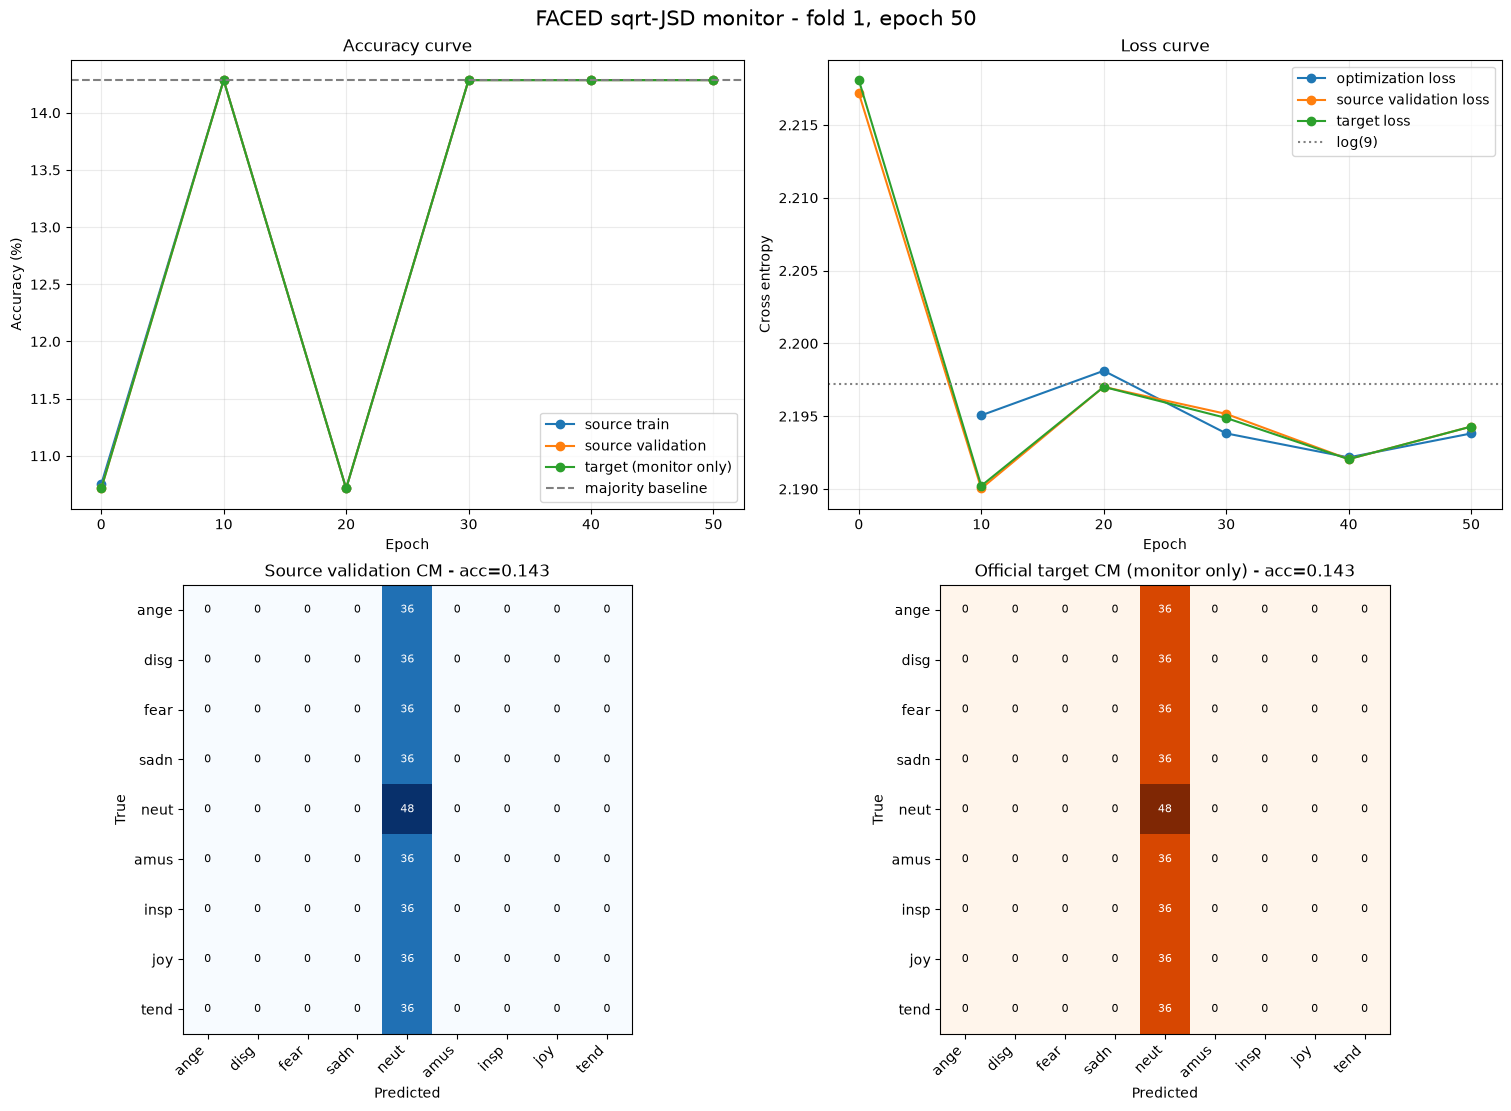

KeyboardInterrupt: 

In [6]:

run_config = {
    key: value for key, value in globals().copy().items()
    if key.isupper() and isinstance(value, (str, int, float, bool, tuple, list, type(None)))
}
with (OUTPUT_DIR / "run_config.json").open("w", encoding="utf-8") as stream:
    json.dump(run_config, stream, indent=2)

history = []
snapshots = []
best_source_validation_f1 = -float("inf")
best_epoch = None
started_at = time.perf_counter()


def run_monitor(epoch, train_loss=float("nan"), mean_grad_norm=float("nan"), maximum_grad_norm=float("nan")):
    global best_source_validation_f1, best_epoch
    source_train_metrics = evaluate_loader(source_train_eval_loader)
    source_validation_metrics = evaluate_loader(source_validation_loader)
    target_metrics = evaluate_loader(target_loader) if target_loader is not None else None
    learning_rate = float(optimizer.param_groups[0]["lr"])
    row = scalar_row(
        epoch, train_loss, learning_rate, mean_grad_norm, maximum_grad_norm,
        source_train_metrics, source_validation_metrics, target_metrics,
    )
    snapshot = {
        "epoch": epoch,
        "source_train": source_train_metrics,
        "source_validation": source_validation_metrics,
        "target": target_metrics,
    }
    history.append(row)
    snapshots.append(snapshot)

    # Selection is source-only. Target metrics are deliberately absent here.
    if source_validation_metrics["macro_f1"] > best_source_validation_f1:
        best_source_validation_f1 = float(source_validation_metrics["macro_f1"])
        best_epoch = epoch
        save_state(OUTPUT_DIR / "best_source_validation.pt", epoch, history, snapshots)
    save_state(OUTPUT_DIR / "last.pt", epoch, history, snapshots)
    persist_monitor(history, snapshots)

    clear_output(wait=True)
    target_text = (
        f"target acc={target_metrics['accuracy']:.4f}, macro-F1={target_metrics['macro_f1']:.4f}"
        if target_metrics is not None else "target monitor disabled"
    )
    print(
        f"Epoch {epoch:3d} | source train acc={source_train_metrics['accuracy']:.4f} | "
        f"source val acc={source_validation_metrics['accuracy']:.4f} | {target_text} | "
        f"lr={learning_rate:.3g}"
    )
    print("Source-val prediction fractions:", np.round(source_validation_metrics["prediction_fractions"], 3))
    if target_metrics is not None:
        print("Target prediction fractions:    ", np.round(target_metrics["prediction_fractions"], 3))
    plot_monitor(history, snapshot)


try:
    if EVALUATE_AT_EPOCH_ZERO:
        run_monitor(0)

    optimizer.zero_grad(set_to_none=True)
    for epoch in range(1, EPOCHS + 1):
        model.train()
        loss_sum = 0.0
        example_count = 0
        gradient_norms = []

        for batch_index, (data, mask, labels) in enumerate(train_loader, 1):
            valid_indices = _valid_indices_on_device(mask, device)
            data = data.to(device, non_blocking=True)
            mask_device = mask.to(device, non_blocking=True)
            labels_device = labels.to(device, non_blocking=True)

            with _autocast({"precision": PRECISION}, device):
                logits = _forward_sequence_model(model, data, mask_device, valid_indices)
                unscaled_loss = criterion(logits, labels_device)
                loss = unscaled_loss / GRADIENT_ACCUMULATION_STEPS

            scaler.scale(loss).backward()
            loss_sum += float(unscaled_loss.detach().item()) * labels.shape[0]
            example_count += int(labels.shape[0])

            is_update = (
                batch_index % GRADIENT_ACCUMULATION_STEPS == 0
                or batch_index == len(train_loader)
            )
            if is_update:
                scaler.unscale_(optimizer)
                if GRADIENT_CLIP_NORM > 0:
                    grad_norm = nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
                else:
                    squared = [p.grad.detach().float().norm(2).square() for p in model.parameters() if p.grad is not None]
                    grad_norm = torch.sqrt(torch.stack(squared).sum()) if squared else torch.tensor(0.0)
                gradient_norms.append(float(grad_norm.detach().cpu()))
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                if scheduler is not None and scheduler_per_update:
                    scheduler.step()

        if scheduler is not None and not scheduler_per_update:
            scheduler.step()

        epoch_loss = loss_sum / max(example_count, 1)
        mean_grad_norm = float(np.mean(gradient_norms)) if gradient_norms else float("nan")
        maximum_grad_norm = float(np.max(gradient_norms)) if gradient_norms else float("nan")
        if epoch % EVAL_INTERVAL == 0 or epoch == EPOCHS:
            run_monitor(epoch, epoch_loss, mean_grad_norm, maximum_grad_norm)
finally:
    for loader in (train_loader, source_train_eval_loader, source_validation_loader, target_loader):
        if loader is not None:
            _shutdown_persistent_loader(loader)

elapsed_seconds = time.perf_counter() - started_at
print(f"Finished in {elapsed_seconds / 60:.1f} min; best source-validation epoch={best_epoch}")


## 7. Compare monitoring checkpoints and diagnose collapse

In [ ]:

monitor_frame = pd.DataFrame(history)
display(monitor_frame.round(4))

final_row = monitor_frame.iloc[-1]
majority_accuracy = 4 / 28
print(f"Majority-class accuracy: {majority_accuracy:.4f}; balanced chance: {1/9:.4f}")
print(f"Best source-validation epoch (source-only selection): {best_epoch}")

source_train_accuracy = float(final_row["source_train_accuracy"])
source_validation_accuracy = float(final_row["source_validation_accuracy"])
target_accuracy = float(final_row.get("target_accuracy", np.nan))
source_dominance = float(final_row["source_train_dominant_prediction_fraction"])
target_dominance = float(final_row.get("target_dominant_prediction_fraction", np.nan))

if source_train_accuracy <= majority_accuracy + 0.03 and source_dominance >= 0.80:
    print("DIAGNOSIS: source training itself collapsed to one class. Prioritize optimizer/LR/precision/loss checks or conclude that this representation supplies too little learnable label signal.")
elif source_train_accuracy >= 0.70 and source_validation_accuracy < source_train_accuracy - 0.20:
    print("DIAGNOSIS: the model fits source-train but does not generalize to unseen source subjects. This is representation/subject overfitting, not simple under-training.")
elif np.isfinite(target_accuracy) and source_validation_accuracy >= 0.40 and target_accuracy < source_validation_accuracy - 0.20:
    print("DIAGNOSIS: source-domain learning works but official target transfer fails; investigate cohort/acquisition domain shift.")
else:
    print("DIAGNOSIS: no single collapse rule fired. Inspect loss, gradient norm, prediction fractions, and the two confusion matrices together.")

if np.isfinite(target_dominance) and target_dominance >= 0.80:
    print("TARGET WARNING: at least 80% of target predictions belong to one class.")



## 8. Suggested manual tests

Change only a small, predeclared parameter group per run and give every run a new `RUN_NAME`.

1. **Numerical/optimization check:** `PRECISION="float32"`, `LABEL_SMOOTHING=0`, then try learning rates `1e-4`, `3e-4`, `1e-3`.
2. **Collapse check:** `CLASS_WEIGHTING="balanced"` and/or `OPTIMIZER="adam"` with zero weight decay.
3. **Capacity check:** first reduce to `D_MODEL=64, LAYERS=2`; only increase capacity if source-train can already rise well above majority baseline.
4. **Scheduler check:** compare `constant` with `cosine_epoch`; do not change several optimizer settings in the same run.

Interpretation rule: if source-train remains near 14.29% across these checks, more hyperparameter searching is unlikely to rescue the unsigned, within-band-normalized sqrt-JSD representation. If source-train becomes high but source-validation/target remain near chance, the issue is cross-subject representation/domain shift rather than optimization.
